In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')
category = pd.read_csv('../data/raw/product_category_name_translation.csv')

In [3]:
print("✅ 데이터 로드 완료!")
print(f"주문: {len(orders):,}건")
print(f"고객: {len(customers):,}명")
print(f"주문상품: {len(order_items):,}건")

✅ 데이터 로드 완료!
주문: 99,441건
고객: 99,441명
주문상품: 112,650건


In [4]:
# 각 테이블 기본 정보 확인
print("=== orders ===")
print(orders.shape)
print(orders.dtypes)
print(orders.isnull().sum())
print()

print("=== customers ===")
print(customers.shape)
print(customers.dtypes)
print(customers.isnull().sum())
print()

print("=== order_items ===")
print(order_items.shape)
print(order_items.dtypes)
print(order_items.isnull().sum())
print()

print("=== order_payments ===")
print(order_payments.shape)
print(order_payments.dtypes)
print(order_payments.isnull().sum())

=== orders ===
(99441, 8)
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== customers ===
(99441, 5)
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city 

In [5]:
# 주문 상태 분포 확인
print("=== 주문 상태 분포 ===")
print(orders['order_status'].value_counts())
print()

# 날짜 컬럼 datetime으로 변환
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# 주문 기간 확인
print("=== 주문 기간 ===")
print(f"시작: {orders['order_purchase_timestamp'].min()}")
print(f"종료: {orders['order_purchase_timestamp'].max()}")
print()

# 결제 수단 분포
print("=== 결제 수단 ===")
print(order_payments['payment_type'].value_counts())

=== 주문 상태 분포 ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

=== 주문 기간 ===
시작: 2016-09-04 21:15:19
종료: 2018-10-17 17:30:18

=== 결제 수단 ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [6]:
# RFM 분석을 위한 핵심 테이블 조인
# delivered 주문만 사용 (실제 완료된 주문)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"완료된 주문: {len(orders_delivered):,}건")

# orders + customers + order_payments 조인
df = orders_delivered.merge(customers, on='customer_id', how='left')
df = df.merge(order_payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')

print(f"조인 후 데이터: {len(df):,}건")
print(f"결측값:\n{df[['customer_unique_id', 'payment_value']].isnull().sum()}")

# 기준일 설정 (데이터 최대 날짜 + 1일)
import datetime
reference_date = orders_delivered['order_purchase_timestamp'].max() + datetime.timedelta(days=1)
print(f"\nRFM 기준일: {reference_date}")

완료된 주문: 96,478건
조인 후 데이터: 96,478건
결측값:
customer_unique_id    0
payment_value         1
dtype: int64

RFM 기준일: 2018-08-30 15:00:37


In [7]:
# 결측값 제거
df = df.dropna(subset=['payment_value'])
print(f"결측값 제거 후: {len(df):,}건")

# RFM 계산
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

print(f"\nRFM 계산 완료: {len(rfm):,}명")
print(f"\n=== RFM 기초 통계 ===")
print(rfm[['recency', 'frequency', 'monetary']].describe())

결측값 제거 후: 96,477건

RFM 계산 완료: 93,357명

=== RFM 기초 통계 ===
            recency     frequency      monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


C:\Users\redti\AppData\Local\Temp\ipykernel_7060\500401572.py:16: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\500401572.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\500401572.py:17: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/rfm_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\500401572.py:17: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/rfm_distribution.png', dpi=150, bbox_inches='tight')
C:\olist-aws-pipeline\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


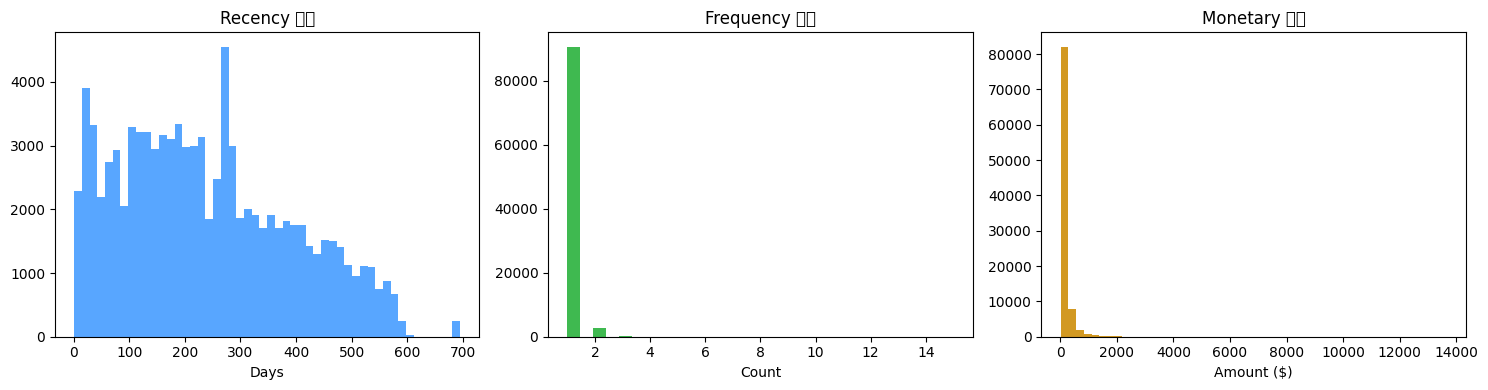

✅ 저장 완료!


In [8]:
# 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['recency'], bins=50, color='#58a6ff', edgecolor='none')
axes[0].set_title('Recency 분포')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['frequency'], bins=30, color='#3fb950', edgecolor='none')
axes[1].set_title('Frequency 분포')
axes[1].set_xlabel('Count')

axes[2].hist(rfm['monetary'], bins=50, color='#d29922', edgecolor='none')
axes[2].set_title('Monetary 분포')
axes[2].set_xlabel('Amount ($)')

plt.tight_layout()
plt.savefig('../docs/rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료!")

C:\Users\redti\AppData\Local\Temp\ipykernel_7060\3623095777.py:23: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/elbow_method.png', dpi=150, bbox_inches='tight')
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\3623095777.py:23: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/elbow_method.png', dpi=150, bbox_inches='tight')
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\3623095777.py:23: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/elbow_method.png', dpi=150, bbox_inches='tight')
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\3623095777.py:23: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig('../docs/elbow_method.png', dpi=150, bbox_inches='tight')
C:\Users\redti\AppData\Local\Temp\ipykernel_7060\3623095777.py:23: UserWarning: Glyph 49828 (\N{HANGUL

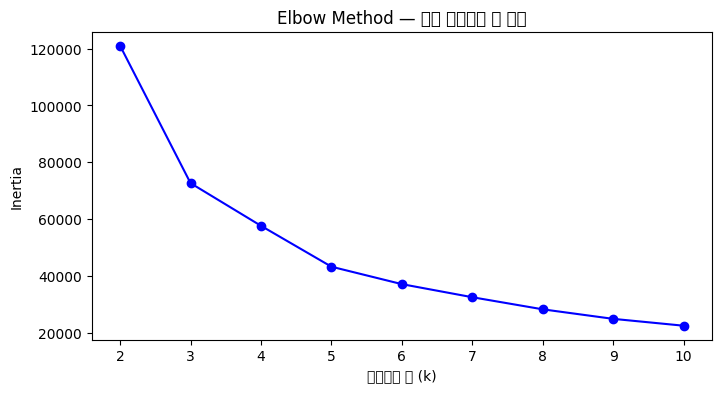

✅ 완료!


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# R과 M만 스케일링
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'monetary']])

# 최적 클러스터 수 찾기 (Elbow Method)
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — 최적 클러스터 수 찾기')
plt.savefig('../docs/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 완료!")

In [10]:
# k=4로 K-Means 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# 클러스터별 R, M 평균
cluster_summary = rfm.groupby('cluster').agg(
    recency=('recency', 'mean'),
    frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean'),
    count=('customer_unique_id', 'count')
).reset_index()

print("=== 클러스터별 특성 ===")
print(cluster_summary.round(1))


=== 클러스터별 특성 ===
   cluster  recency  frequency  monetary  count
0        0     87.2        1.0     140.5  34978
1        1    254.8        1.0     134.3  34416
2        2    235.9        1.1    1139.8   2624
3        3    458.0        1.0     135.5  21339


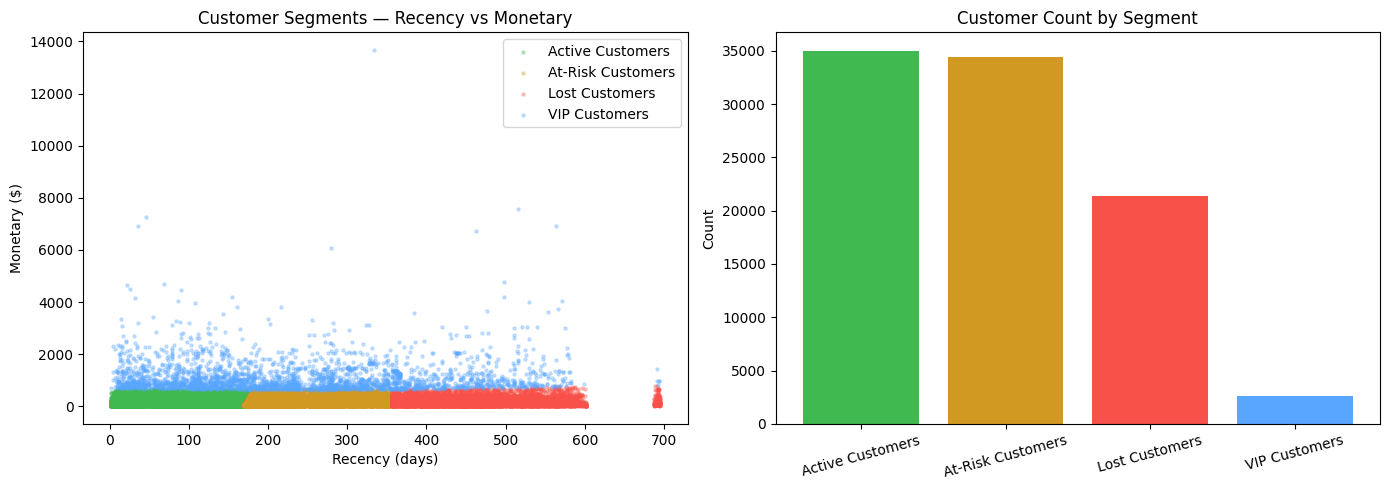

✅ 완료!


In [11]:
# 클러스터 이름 붙이기
cluster_names = {
    0: 'Active Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Lost Customers'
}
rfm['segment'] = rfm['cluster'].map(cluster_names)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Active Customers': '#3fb950', 'VIP Customers': '#58a6ff',
          'At-Risk Customers': '#d29922', 'Lost Customers': '#f85149'}

# 산점도 — Recency vs Monetary
for segment, group in rfm.groupby('segment'):
    axes[0].scatter(group['recency'], group['monetary'],
                   label=segment, alpha=0.3, s=5, color=colors[segment])
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary ($)')
axes[0].set_title('Customer Segments — Recency vs Monetary')
axes[0].legend()

# 세그먼트별 고객 수
segment_counts = rfm['segment'].value_counts()
axes[1].bar(segment_counts.index, segment_counts.values,
           color=[colors[s] for s in segment_counts.index])
axes[1].set_title('Customer Count by Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../docs/customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 완료!")